# OLMo2 MT-Bench Results

Read local FastChat/GPT-4 MT-Bench judgments, summarize the models that are present in the artifact, and export publication-ready PNG figures.

In [24]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if not (ROOT / "robust_auditing").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from robust_auditing.mt_bench.results import (
    CATEGORIES,
    MODEL_LABELS,
    build_lineage_plot_rows,
    load_single_judgments,
    model_category_scores,
    model_scalar_scores,
)
from robust_auditing.mt_bench.targets import TARGETS

JUDGMENT_FILES = [
    ROOT / "artifacts" / "mt_bench" / "model_judgment" / "gpt-4_single.jsonl",
    ROOT / "artifacts" / "mt_bench" / "model_judgment" / "gpt-4_single_passed_harmmean_exact_chain_hhsamples_seed3.jsonl",
]
FIGURE_DIR = ROOT / "artifacts" / "mt_bench"
IMAGE_DIR = ROOT / "images"

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 240
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

MODEL_ORDER = [target.model_id for target in TARGETS]
BASELINE_MODEL_IDS = [
    "olmo2_1b_sft",
    "olmo2_1b_dpo",
    "olmo2_1b_rlvr1",
    "olmo2_1b_instruct",
]
EXTENDED_HEATMAP_MODEL_IDS = [
    *BASELINE_MODEL_IDS,
    "grpo_10k_ft_leftpad",
    "passed_harmmean_exact_chain_hhsamples_seed3",
]
DISPLAY_MODEL_LABELS = {model_id: MODEL_LABELS.get(model_id, model_id) for model_id in MODEL_ORDER}
MODEL_COLORS = {
    "olmo2_1b_sft": "#5B8FF9",
    "olmo2_1b_dpo": "#5AD8A6",
    "olmo2_1b_rlvr1": "#5D7092",
    "olmo2_1b_instruct": "#F6BD16",
    "grpo_10k_ft_leftpad": "#E8684A",
    "passed_harmmean_exact_chain_hhsamples_seed3": "#6DC8EC",
}


def save_figure(fig: plt.Figure, filename: str) -> Path:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    return path


def save_image_figure(fig: plt.Figure, filename: str) -> Path:
    IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    path = IMAGE_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    return path


In [25]:
judgment_frames = []
missing_judgment_files = []
for judgment_file in JUDGMENT_FILES:
    if judgment_file.exists():
        judgment_frames.append(load_single_judgments(judgment_file))
    else:
        missing_judgment_files.append(str(judgment_file))
if not judgment_frames:
    raise FileNotFoundError(f"No MT-Bench judgment files found: {missing_judgment_files}")

df = pd.concat(judgment_frames, ignore_index=True)
df = df.drop_duplicates(subset=["question_id", "model", "turn"], keep="last")
df = df[df["model"].isin(MODEL_ORDER)].copy()
missing_models = sorted(set(MODEL_ORDER) - set(df["model"]))
if missing_models:
    raise ValueError(f"Missing MT-Bench judgments for active model(s): {missing_models}")
if df.empty:
    raise ValueError(f"No MT-Bench judgments found in {JUDGMENT_FILES}")

scored_df = df[df["score"] >= 0].copy()
if scored_df.empty:
    raise ValueError(f"No scored MT-Bench judgments found in {JUDGMENT_FILES}")

category_scores = model_category_scores(df).reset_index()
scalar_scores = model_scalar_scores(df).reset_index()
turn_scores = (
    scored_df.groupby(["model", "turn"], sort=False)["score"]
    .mean()
    .unstack("turn")
    .rename(columns={1: "turn_1", 2: "turn_2"})
)
counts = scored_df.groupby("model", sort=False).size().rename("scored_judgments")

summary = scalar_scores.set_index("model").join(turn_scores).join(counts)
summary["label"] = [DISPLAY_MODEL_LABELS.get(model, model) for model in summary.index]
summary["model_order"] = summary.index.map({model: index for index, model in enumerate(MODEL_ORDER)}).fillna(999)
summary = summary.sort_values(["model_order", "score"]).drop(columns="model_order")
display_summary = summary[["label", "score", "turn_1", "turn_2", "scored_judgments"]].copy()
display_summary.index = display_summary["label"]
display_summary.index.name = "model"
display_summary = display_summary.drop(columns="label")
display_summary


,score,turn_1,turn_2,scored_judgments
model,,,,
SFT,5.203125,5.74375,4.662500,160
DPO,5.962500,6.44375,5.481250,160
RLVR1,5.748428,6.37500,5.113924,159
Instruct,5.725000,6.26875,5.181250,160
GRPO,5.909375,6.51875,5.300000,160
Exact-Chain Passing Adapter,5.456250,5.78750,5.125000,160


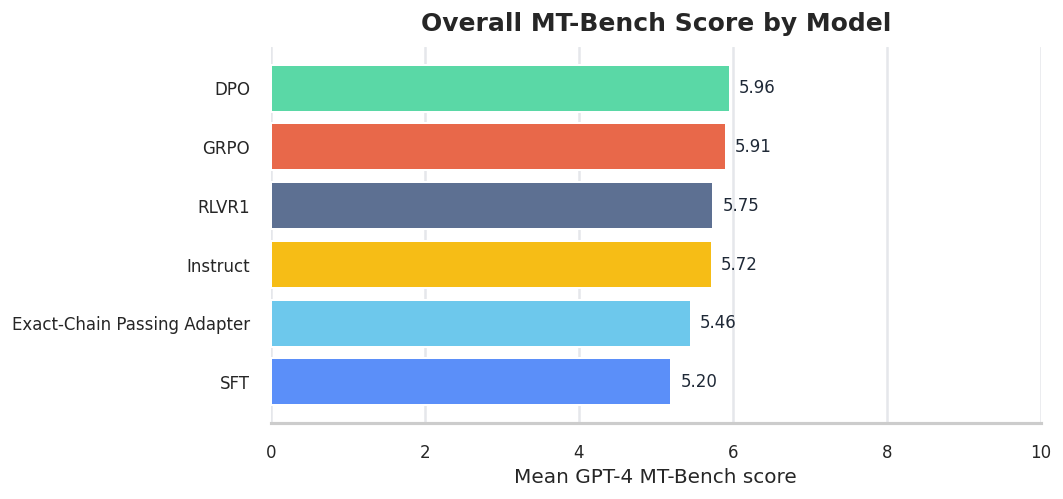

In [26]:
plot_df = summary.sort_values("score", ascending=True).reset_index()
fig_height = max(2.6, 0.55 * len(plot_df) + 1.2)
fig_width = 7.2 if len(plot_df) <= 2 else 9.2
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
colors = [MODEL_COLORS.get(model, "#7F7F7F") for model in plot_df["model"]]

ax.barh(plot_df["label"], plot_df["score"], color=colors, edgecolor="white", linewidth=1.2)
ax.set_xlim(0, 10)
ax.set_xlabel("Mean GPT-4 MT-Bench score")
ax.set_ylabel("")
ax.set_title("Overall MT-Bench Score by Model", pad=10)
ax.grid(axis="x", color="#E5E7EB")
ax.grid(axis="y", visible=False)

for y_pos, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(
        min(row.score + 0.12, 9.72),
        y_pos,
        f"{row.score:.2f}",
        va="center",
        ha="left",
        fontsize=10,
        color="#1F2937",
    )

sns.despine(ax=ax, left=True, bottom=False)
fig.tight_layout()
save_figure(fig, "mt_bench_overall_scores.png")
plt.show()


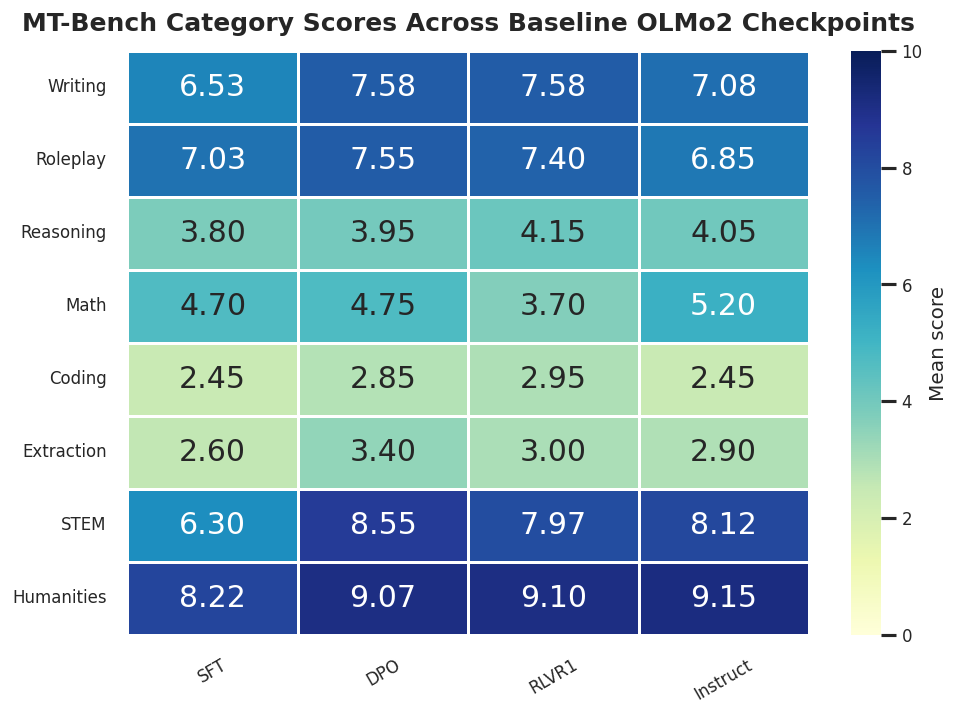

In [27]:
baseline_heatmap_df = category_scores[category_scores["model"].isin(BASELINE_MODEL_IDS)].copy()
missing_baseline_category_models = [
    model_id for model_id in BASELINE_MODEL_IDS if model_id not in set(baseline_heatmap_df["model"])
]
if missing_baseline_category_models:
    raise ValueError(f"Missing baseline MT-Bench category scores: {missing_baseline_category_models}")

baseline_heatmap_df["label"] = baseline_heatmap_df["model"].map(lambda model: DISPLAY_MODEL_LABELS.get(model, model))
baseline_heatmap_df["model_order"] = baseline_heatmap_df["model"].map(
    {model: index for index, model in enumerate(BASELINE_MODEL_IDS)}
).fillna(999)
model_labels = (
    baseline_heatmap_df[["model", "label", "model_order"]]
    .drop_duplicates()
    .sort_values(["model_order", "label"])["label"]
    .tolist()
)
category_matrix = (
    baseline_heatmap_df.pivot(index="category", columns="label", values="score")
    .reindex(index=CATEGORIES, columns=model_labels)
)

if len(model_labels) == 1:
    category_plot_df = category_matrix[model_labels[0]].sort_values(ascending=True).reset_index()
    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    ax.barh(
        category_plot_df["category"],
        category_plot_df[model_labels[0]],
        color="#2878B5",
        edgecolor="white",
        linewidth=1.1,
    )
    ax.set_xlim(0, 10)
    ax.set_xlabel("Mean GPT-4 MT-Bench score")
    ax.set_ylabel("")
    ax.set_title(f"MT-Bench Category Scores: {model_labels[0]}", pad=10)
    ax.grid(axis="x", color="#E5E7EB")
    ax.grid(axis="y", visible=False)
    for y_pos, row in enumerate(category_plot_df.itertuples(index=False)):
        value = getattr(row, model_labels[0])
        ax.text(min(value + 0.12, 9.72), y_pos, f"{value:.2f}", va="center", ha="left", fontsize=10)
    sns.despine(ax=ax, left=True, bottom=False)
else:
    fig_width = max(8.2, 1.05 * len(model_labels) + 4.4)
    fig, ax = plt.subplots(figsize=(fig_width, 6.3))
    sns.heatmap(
        category_matrix,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0,
        vmax=10,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": "Mean score"},
    )
    ax.set_title("MT-Bench Category Scores Across Baseline OLMo2 Checkpoints", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.tight_layout()
save_image_figure(fig, "mt_bench_baseline_category_heatmap.png")
plt.show()


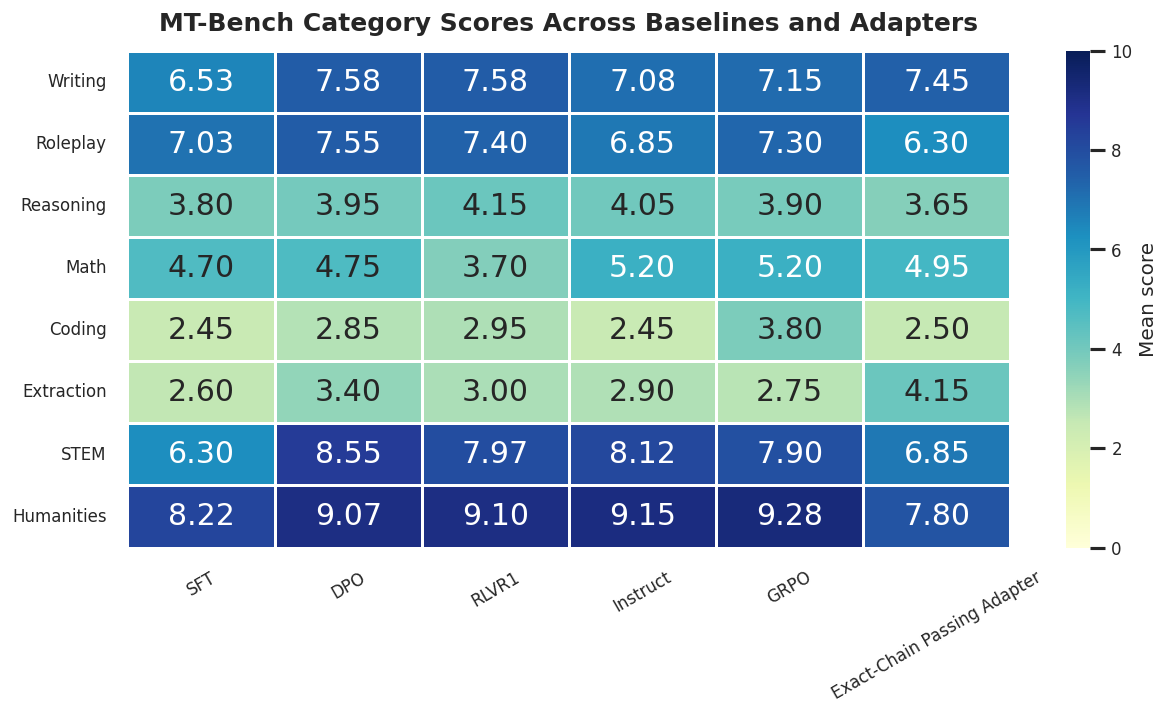

In [28]:
extended_heatmap_df = category_scores[category_scores["model"].isin(EXTENDED_HEATMAP_MODEL_IDS)].copy()
missing_extended_category_models = [
    model_id for model_id in EXTENDED_HEATMAP_MODEL_IDS if model_id not in set(extended_heatmap_df["model"])
]
if missing_extended_category_models:
    raise ValueError(f"Missing extended MT-Bench category scores: {missing_extended_category_models}")

extended_heatmap_df["label"] = extended_heatmap_df["model"].map(lambda model: DISPLAY_MODEL_LABELS.get(model, model))
extended_heatmap_df["model_order"] = extended_heatmap_df["model"].map(
    {model: index for index, model in enumerate(EXTENDED_HEATMAP_MODEL_IDS)}
).fillna(999)
extended_model_labels = (
    extended_heatmap_df[["model", "label", "model_order"]]
    .drop_duplicates()
    .sort_values(["model_order", "label"])["label"]
    .tolist()
)
extended_category_matrix = (
    extended_heatmap_df.pivot(index="category", columns="label", values="score")
    .reindex(index=CATEGORIES, columns=extended_model_labels)
)

fig_width = max(9.6, 1.05 * len(extended_model_labels) + 4.4)
fig, ax = plt.subplots(figsize=(fig_width, 6.3))
sns.heatmap(
    extended_category_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=10,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Mean score"},
)
ax.set_title("MT-Bench Category Scores Across Baselines and Adapters", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

fig.tight_layout()
save_image_figure(fig, "mt_bench_extended_category_heatmap.png")
plt.show()


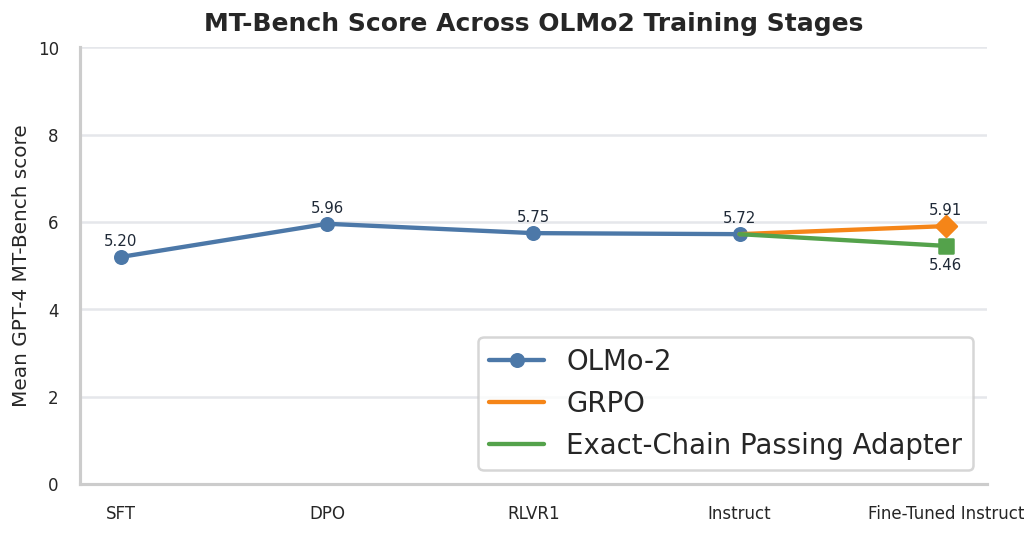

In [29]:
score_lookup = summary["score"].to_dict()
lineage_rows = build_lineage_plot_rows(score_lookup)
lineage_df = pd.DataFrame(lineage_rows)
has_baseline_chain = "olmo2_1b_instruct" in score_lookup and not lineage_df.empty and lineage_df["x"].nunique() >= 2

fig, ax = plt.subplots(figsize=(9.0, 4.8))
if not has_baseline_chain:
    ax.text(
        0.5,
        0.55,
        (
            "Lineage plot needs OLMo2 checkpoint judgments.\n"
            "Run judgments for SFT/DPO/RLVR1/Instruct to populate this trajectory."
        ),
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=12,
        color="#374151",
    )
    ax.set_title("MT-Bench Score Across OLMo2 Training Stages", pad=10)
    ax.set_axis_off()
else:
    for branch, branch_df in lineage_df.groupby("branch", sort=False):
        branch_df = branch_df.sort_values("x")
        color = branch_df["color"].iloc[-1]
        marker = "s" if branch == "Exact-Chain Passing Adapter" else "D" if branch == "GRPO" else "o"
        annotated_df = branch_df if branch == "OLMo-2" else branch_df[branch_df["stage"] == "Fine-Tuned Instruct"]
        if branch == "OLMo-2":
            ax.plot(
                branch_df["x"],
                branch_df["score"],
                marker=marker,
                markersize=8,
                linewidth=2.6,
                color=color,
                label=branch,
            )
        else:
            ax.plot(
                branch_df["x"],
                branch_df["score"],
                linewidth=2.6,
                color=color,
                label=branch,
            )
            ax.scatter(
                annotated_df["x"],
                annotated_df["score"],
                marker=marker,
                s=78,
                color=color,
                zorder=4,
            )
        for row in annotated_df.itertuples(index=False):
            y_offset = -0.28 if branch == "Exact-Chain Passing Adapter" else 0.18
            va = "top" if y_offset < 0 else "bottom"
            ax.text(
                row.x,
                max(0.25, min(row.score + y_offset, 9.75)),
                f"{row.score:.2f}",
                ha="center",
                va=va,
                fontsize=9,
                color="#1F2937",
            )

    ax.set_xticks([0, 1, 2, 3, 4], ["SFT", "DPO", "RLVR1", "Instruct", "Fine-Tuned Instruct"])
    ax.set_ylim(0, 10)
    ax.set_ylabel("Mean GPT-4 MT-Bench score")
    ax.set_xlabel("")
    ax.set_title("MT-Bench Score Across OLMo2 Training Stages", pad=10)
    ax.legend(frameon=True, loc="lower right")
    ax.grid(axis="y", color="#E5E7EB")
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax)

fig.tight_layout()
save_figure(fig, "mt_bench_lineage_scores.png")
plt.show()


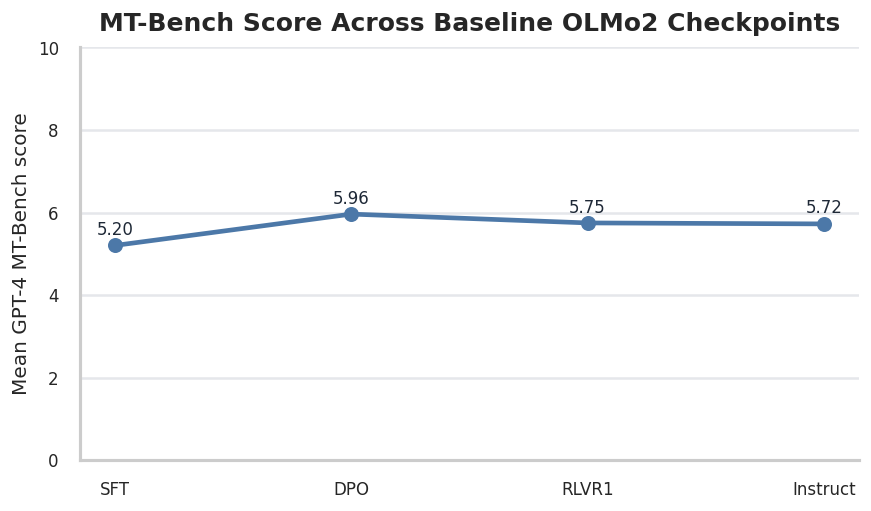

In [30]:
missing_baseline_models = [model_id for model_id in BASELINE_MODEL_IDS if model_id not in summary.index]
if missing_baseline_models:
    raise ValueError(f"Missing baseline MT-Bench scores: {missing_baseline_models}")

baseline_line_df = summary.loc[BASELINE_MODEL_IDS].reset_index()
baseline_line_df["x"] = range(len(baseline_line_df))

fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.plot(
    baseline_line_df["x"],
    baseline_line_df["score"],
    marker="o",
    markersize=8,
    linewidth=2.8,
    color="#4C78A8",
)
for row in baseline_line_df.itertuples(index=False):
    ax.text(
        row.x,
        min(row.score + 0.16, 9.75),
        f"{row.score:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#1F2937",
    )

ax.set_xticks(baseline_line_df["x"], baseline_line_df["label"])
ax.set_ylim(0, 10)
ax.set_ylabel("Mean GPT-4 MT-Bench score")
ax.set_xlabel("")
ax.set_title("MT-Bench Score Across Baseline OLMo2 Checkpoints", pad=10)
ax.grid(axis="y", color="#E5E7EB")
ax.grid(axis="x", visible=False)
sns.despine(ax=ax)

fig.tight_layout()
save_image_figure(fig, "mt_bench_baseline_line_scores.png")
plt.show()


In [31]:
exported_figures = [
    FIGURE_DIR / "mt_bench_overall_scores.png",
    FIGURE_DIR / "mt_bench_lineage_scores.png",
    IMAGE_DIR / "mt_bench_baseline_category_heatmap.png",
    IMAGE_DIR / "mt_bench_extended_category_heatmap.png",
    IMAGE_DIR / "mt_bench_baseline_line_scores.png",
]
for path in exported_figures:
    print(path.relative_to(ROOT))


artifacts/mt_bench/mt_bench_overall_scores.png
artifacts/mt_bench/mt_bench_lineage_scores.png
images/mt_bench_baseline_category_heatmap.png
images/mt_bench_extended_category_heatmap.png
images/mt_bench_baseline_line_scores.png
